# Import's & Dataloaders

In [4]:
import pandas as pd
from pathlib import Path

# Create a base directory (relative path)
data_dir = Path("Data")

marketData = pd.read_csv(data_dir / "slim_massachusetts_market_data.csv")

# Skiprows for not reading the reader of the files

Crime2024 = pd.read_csv(data_dir / "Number of Crimes by Offense Type_2024.csv", skiprows=5)
Crime2023 = pd.read_csv(data_dir / "Number of Crimes by Offense Type_2023.csv", skiprows=5)
Crime2022 = pd.read_csv(data_dir / "Number of Crimes by Offense Type_2022.csv", skiprows=5)
Crime2021 = pd.read_csv(data_dir / "Number of Crimes by Offense Type_2021.csv", skiprows=5)
Crime2020 = pd.read_csv(data_dir / "Number of Crimes by Offense Type_2020.csv", skiprows=5)
Crime2019 = pd.read_csv(data_dir / "Number of Crimes by Offense Type_2019.csv", skiprows=5)
Crime2017 = pd.read_csv(data_dir / "Number of Crimes by Offense Type_2017.csv", skiprows=5)
Crime2016 = pd.read_csv(data_dir / "Number of Crimes by Offense Type_2016.csv", skiprows=5)
Crime2015 = pd.read_csv(data_dir / "Number of Crimes by Offense Type_2015.csv", skiprows=5)

# David Arzumanyan

# Joe Tivnan

In [ ]:

# take the merketData and remove the 'IS_SEASONALLY_ADJUSTED' column
slim_marketData = marketData.drop(columns=['IS_SEASONALLY_ADJUSTED',
                                           'OFF_MARKET_IN_TWO_WEEKS',
                                           'OFF_MARKET_IN_TWO_WEEKS_MOM',
                                           'OFF_MARKET_IN_TWO_WEEKS_YOY',
                                           'MEDIAN_SALE_PRICE',
                                           'MEDIAN_SALE_PRICE_MOM',
                                           'MEDIAN_SALE_PRICE_YOY',
                                           'LAST_UPDATED'])


# download the slim_marketData
slim_marketData.to_csv("Data/slim_massachusetts_market_data.csv", index=False)

0         1.012871
1         1.023022
2         1.019695
3         1.040822
4         0.953878
            ...   
240293    1.021338
240294    1.025257
240295    1.075758
240296    1.001541
240297    0.983954
Name: AVG_SALE_TO_LIST, Length: 240298, dtype: float64

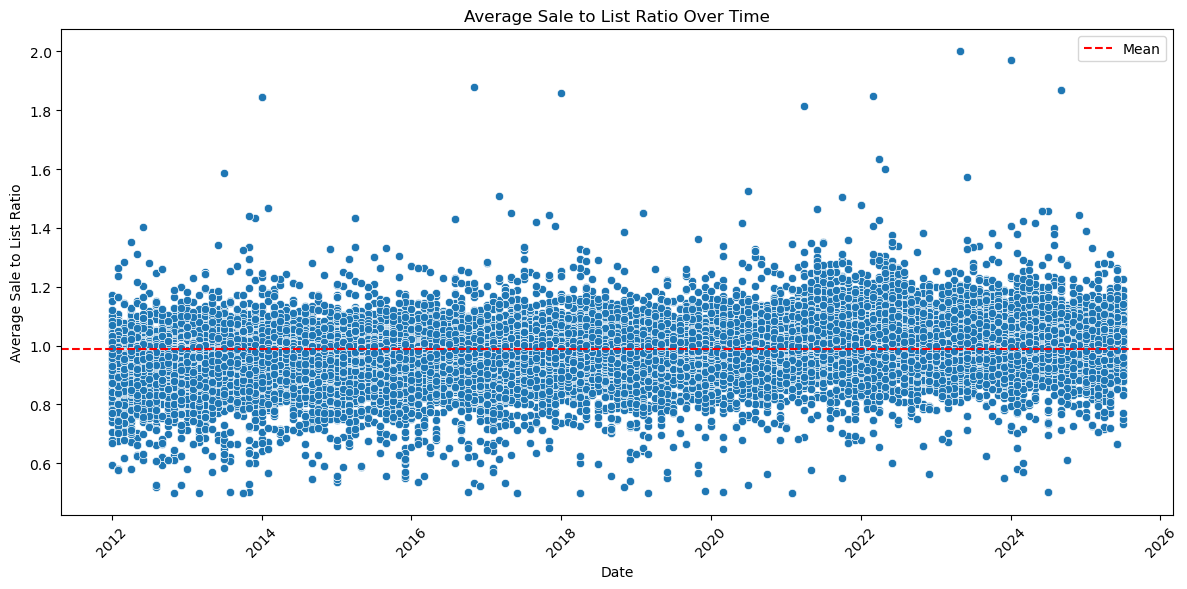

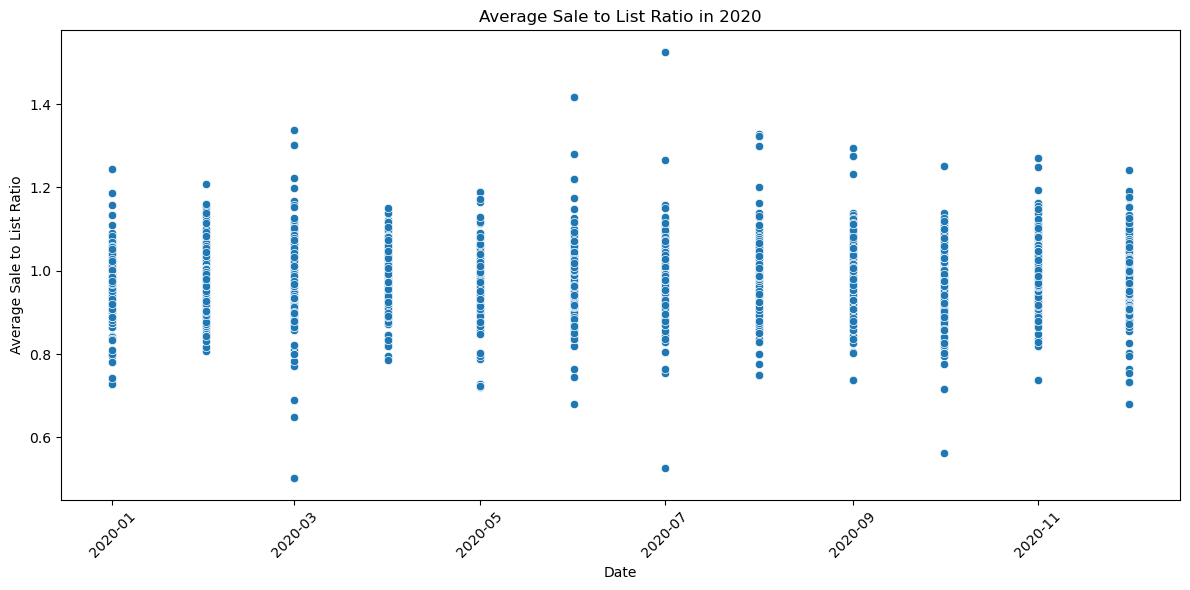

C:\Users\FTrou\AppData\Local\Temp\ipykernel_12280\2554096580.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marketData_2020['MONTH'] = marketData_2020['PERIOD_BEGIN'].dt.month


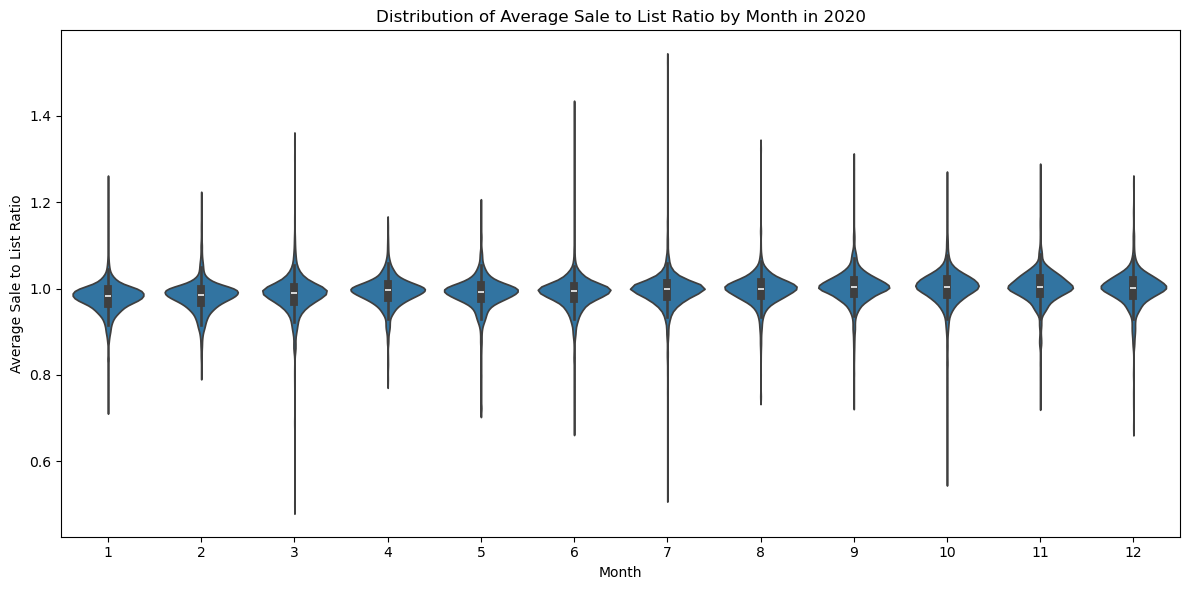

In [ ]:
display(marketData['AVG_SALE_TO_LIST'])

# plot a scatter plot in seaborn of AVG_SALE_TO_LIST vs DATE, using YYYY-MM-DD format for the BEGIN_PERIOD column
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the 'BEGIN_PERIOD' column to datetime format
marketData['PERIOD_BEGIN'] = pd.to_datetime(marketData['PERIOD_BEGIN'])

# Create the scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=marketData, x='PERIOD_BEGIN', y='AVG_SALE_TO_LIST')
plt.title('Average Sale to List Ratio Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sale to List Ratio')
plt.xticks(rotation=45)
plt.tight_layout()

# add a mean line to the scatter plot and add a legend
mean_value = marketData['AVG_SALE_TO_LIST'].mean()
plt.axhline(mean_value, color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

# plot just the values from 2020
marketData_2020 = marketData[marketData['PERIOD_BEGIN'].dt.year == 2020]
plt.figure(figsize=(12, 6))
sns.scatterplot(data=marketData_2020, x='PERIOD_BEGIN', y='AVG_SALE_TO_LIST')
plt.title('Average Sale to List Ratio in 2020')
plt.xlabel('Date')
plt.ylabel('Average Sale to List Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# create a violin plot of all the distributions for 2020 by month
marketData_2020['MONTH'] = marketData_2020['PERIOD_BEGIN'].dt.month
plt.figure(figsize=(12, 6))
sns.violinplot(data=marketData_2020, x='MONTH', y='AVG_SALE_TO_LIST')
plt.title('Distribution of Average Sale to List Ratio by Month in 2020')
plt.xlabel('Month')
plt.ylabel('Average Sale to List Ratio')
plt.tight_layout()
plt.show()

In [ ]:
# Scatter plot of AVG_SALE_TO_LIST colored by year
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure PERIOD_BEGIN is datetime and create year column
marketData['PERIOD_BEGIN'] = pd.to_datetime(marketData['PERIOD_BEGIN'], errors='coerce')
marketData['year'] = marketData['PERIOD_BEGIN'].dt.year

# Drop rows with missing year or missing AVG_SALE_TO_LIST
plot_df = marketData.dropna(subset=['year', 'AVG_SALE_TO_LIST']).copy()
plot_df['year'] = plot_df['year'].astype(int)

# Use a discrete palette for years present
years = sorted(plot_df['year'].unique())
palette = sns.color_palette('tab10', n_colors=len(years))

plt.figure(figsize=(12,6))
# To keep the scatter from being too dense, set alpha and edgecolor
sns.scatterplot(data=plot_df, x='PERIOD_BEGIN', y='AVG_SALE_TO_LIST', hue='year', palette=palette, legend='full', s=25, alpha=0.7)
plt.title('AVG_SALE_TO_LIST Over Time (colored by Year)')
plt.xlabel('Date')
plt.ylabel('Average Sale to List Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

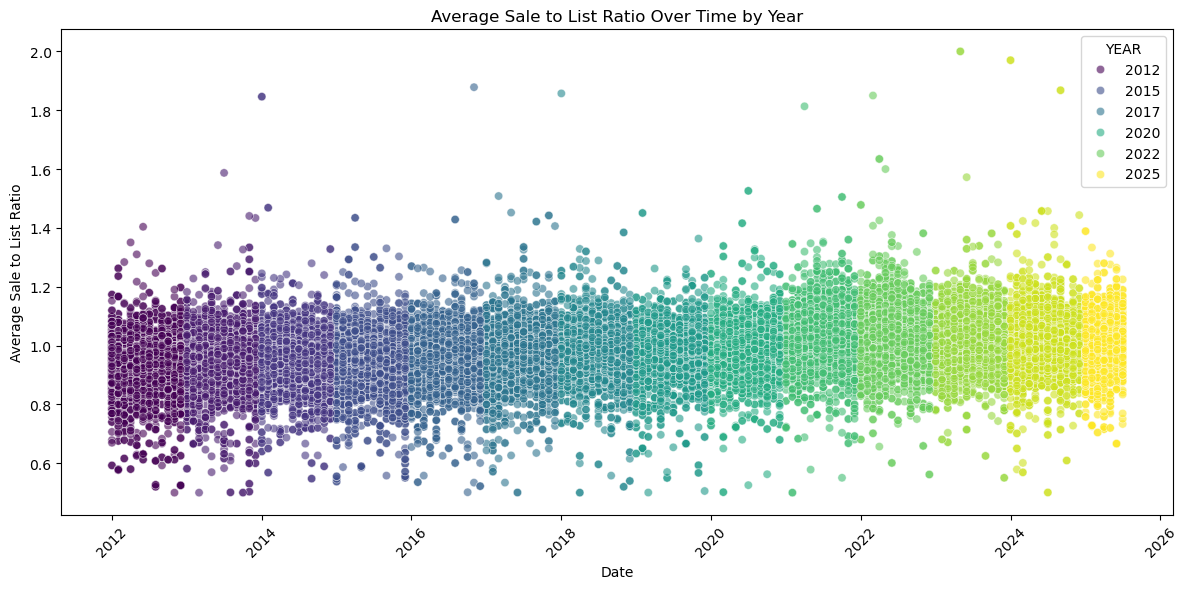

# Patrick Keufack

In [ ]:
print("Hello World!")

# Victor

In [ ]:
# Check Data

print("Rows and Columns:", Crime2024.shape)
print("\nColumns:", Crime2024.columns.tolist())
print("\nData Types:")
print(Crime2024.dtypes)
print("\nPreview:")
print(Crime2024.head())